# Donor Churn / Lapse-Risk Classifier
## Faro Safehouse — INTEX W26

---

## 1. Problem Framing

### Business Question

> **Which donors are at risk of lapsing so the organization can proactively re-engage them?**

### Why It Matters

Faro Safehouse operates safehouses in Chile for survivors of trafficking and abuse. The organization relies on donations — monetary gifts, in-kind contributions, volunteer time, and professional skills — to sustain daily operations. Losing donors silently is costly: re-acquiring a lapsed donor is far more expensive than retaining an active one. Early identification of at-risk donors allows targeted outreach before the relationship goes cold.

### Predictive vs. Explanatory

This notebook contains two complementary components:

1. **PREDICTIVE pipeline** — a supervised classifier that outputs a churn probability score for every donor, enabling the operations team to prioritize re-engagement efforts.
2. **EXPLANATORY model** — a statsmodels Logit regression that produces odds ratios, p-values, and confidence intervals so stakeholders can understand *what drives* lapse behavior.

### Success Metrics

| Metric | Purpose |
|---|---|
| **ROC-AUC** | Discrimination — can the model separate active from at-risk donors? |
| **F1 Score** | Balance between precision and recall on the minority (at-risk) class |
| **Accuracy vs. Baseline** | Does the model beat always-predict-majority? |

### The 75th-Percentile Threshold

Instead of an arbitrary "180 days" cutoff, we use a **data-driven 75th percentile** of each donor's recency (days since last donation). Donors in the top quartile of inactivity are labeled "at risk." This threshold adapts automatically as the donor base evolves — if overall engagement improves, the cutoff tightens; if engagement declines, it relaxes. By definition, approximately 25% of donors will be flagged, giving the team a manageable outreach list.

### Data Leakage Prevention

`recency_days` is the feature used to *define* the target variable (`is_at_risk = recency_days > 75th percentile`). Including it as a model feature would be textbook **data leakage** — the model would trivially learn "donors who haven't donated recently are at risk" with near-perfect accuracy but zero practical usefulness. We **exclude** `recency_days` from the feature set so the model must learn from behavioral patterns (frequency, monetary value, donation diversity, tenure, recurring status) that *predict* future lapse before it happens.

---

## 2. Data Acquisition, Preparation & Exploration

### Data Sources

| File | Description | Rows |
|---|---|---|
| `supporters.csv` | Supporter demographics — type, region, country, acquisition channel, contact info | ~60 |
| `donations.csv` | Individual donation records — amount, type, channel, campaign, date, recurring flag | ~420 |

### RFM Framework

We apply the industry-standard **RFM framework** (Recency, Frequency, Monetary) — a well-established approach in donor and customer analytics — to summarize each supporter's donation behavior into predictive features. We extend beyond basic RFM with additional behavioral signals: donation type variety, recurring donation status, tenure, channel diversity, campaign engagement, and average gap between donations.

In total, 17 engineered features capture the full picture of each donor's engagement pattern.

In [50]:
# ── Imports ──────────────────────────────────────────────────────────
import json
import warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV, cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

SEED = 42
print("Imports complete.")

from scipy import stats
from sklearn.metrics import log_loss
from sklearn.tree import plot_tree
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier


Imports complete.


### 2.1 Load Raw Data

In [51]:
# ── Load CSVs ────────────────────────────────────────────────────────
supporters = pd.read_csv("data/supporters.csv")
donations  = pd.read_csv("data/donations.csv")

donations["donation_date"] = pd.to_datetime(donations["donation_date"])

print(f"Supporters: {supporters.shape}")
print(f"Donations:  {donations.shape}")
display(supporters.head(3))
display(donations.head(3))

Supporters: (60, 15)
Donations:  (420, 13)


,supporter_id,supporter_type,display_name,organization_name,first_name,last_name,relationship_type,region,country,email,phone,status,created_at,first_donation_date,acquisition_channel
0,1,SocialMediaAdvocate,Mila Alvarez,NaN,Mila,Alvarez,Local,Luzon,Philippines,mila-alvarez@smart.com.ph,+63 997 578 1887,Active,2022-01-01 00:00:00,2023-07-02,SocialMedia
1,2,Volunteer,Aria Brown,NaN,Aria,Brown,Local,Mindanao,Philippines,aria-brown@pldt.net.ph,+63 927 354 4139,Active,2022-01-06 00:00:00,2023-09-25,SocialMedia
2,3,MonetaryDonor,Noah Chen,NaN,Noah,Chen,Local,Luzon,Philippines,noah-chen@globe.com.ph,+63 917 553 2604,Active,2022-01-11 00:00:00,2023-06-25,SocialMedia


,donation_id,supporter_id,donation_type,donation_date,is_recurring,campaign_name,channel_source,currency_code,amount,estimated_value,impact_unit,notes,referral_post_id
0,1,42,Monetary,2025-12-31,False,NaN,Campaign,PHP,717.18,717.18,pesos,In support of safehouse operations,NaN
1,2,25,Time,2025-12-02,True,Year-End Hope,Event,NaN,NaN,35.15,hours,Community outreach support,NaN
2,3,19,Monetary,2024-12-02,False,NaN,PartnerReferral,PHP,1074.65,1074.65,pesos,Campaign support,NaN


### 2.2 Exploratory Data Analysis

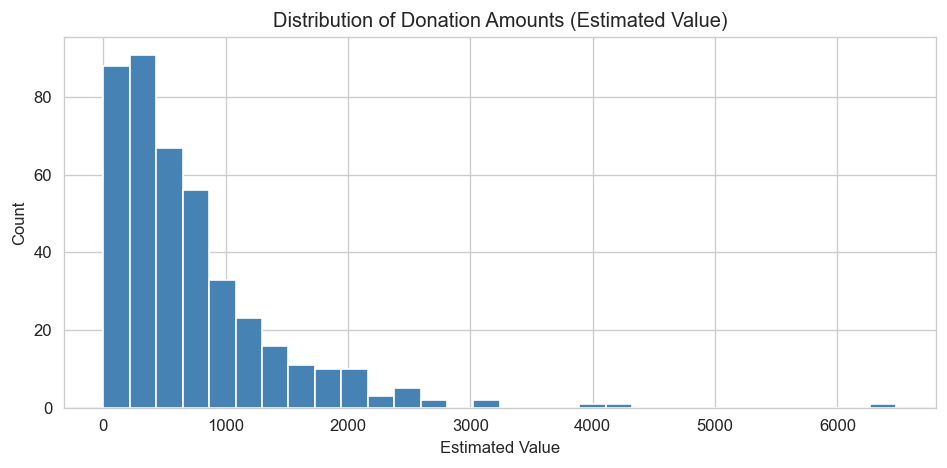

In [52]:
# ── Donation amount distribution ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
donations["estimated_value"].dropna().hist(
    bins=30, ax=ax, edgecolor="white", color="steelblue"
)
ax.set_title("Distribution of Donation Amounts (Estimated Value)")
ax.set_xlabel("Estimated Value")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

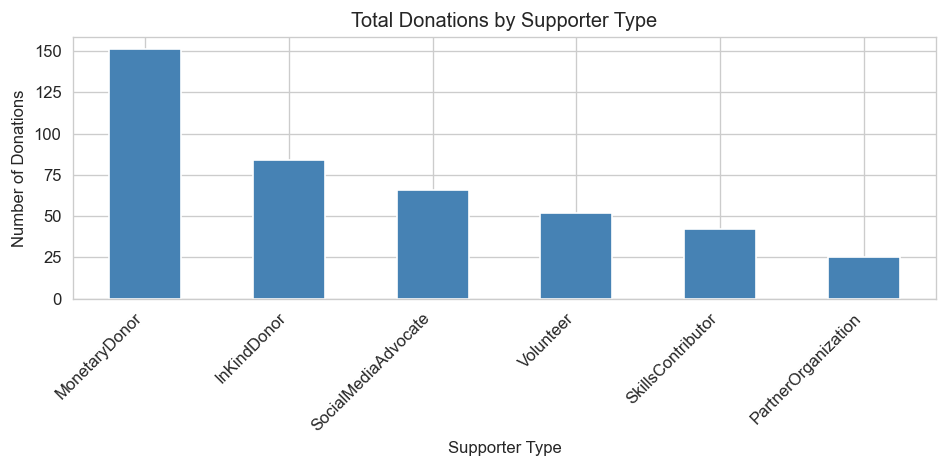

In [53]:
# ── Donation frequency by supporter type ────────────────────────────
freq_by_type = (
    donations
    .merge(supporters[["supporter_id", "supporter_type"]], on="supporter_id")
    .groupby("supporter_type")["donation_id"]
    .count()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
freq_by_type.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Total Donations by Supporter Type")
ax.set_xlabel("Supporter Type")
ax.set_ylabel("Number of Donations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

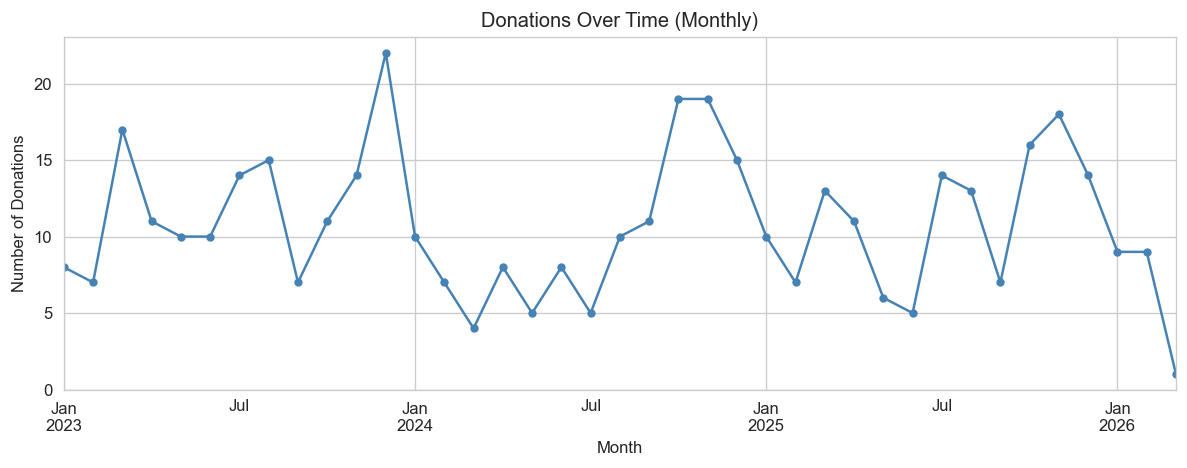

In [54]:
# ── Temporal donation patterns ──────────────────────────────────────
monthly = (
    donations
    .set_index("donation_date")
    .resample("ME")["donation_id"]
    .count()
)

fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(ax=ax, marker="o", color="steelblue", linewidth=1.5, markersize=4)
ax.set_title("Donations Over Time (Monthly)")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Donations")
plt.tight_layout()
plt.show()

### 2.3 Feature Engineering

We engineer 17 features per supporter using the extended RFM framework:

| # | Feature | Source | Description |
|---|---------|--------|-------------|
| 1 | `frequency` | Donation count | Total number of donations |
| 2 | `total_value` | Sum of `estimated_value` | Lifetime monetary value |
| 3 | `avg_donation_value` | Mean of `estimated_value` | Average gift size |
| 4 | `max_donation_value` | Max of `estimated_value` | Largest single gift |
| 5 | `has_recurring` | Max of `is_recurring` | Whether the donor has ever set up recurring |
| 6 | `pct_recurring` | Mean of `is_recurring` | Share of donations that are recurring |
| 7 | `donation_type_variety` | Nunique of `donation_type` | How many different types (monetary, in-kind, volunteer, skills) |
| 8 | `channel_variety` | Nunique of `channel_source` | How many different channels used |
| 9 | `campaigns_donated_to` | Nunique of `campaign_name` | Breadth of campaign engagement |
| 10 | `avg_gap_days` | Mean gap between consecutive donations | Donation cadence regularity |
| 11 | `tenure_days` | Days from first donation to reference date | Length of relationship |
| 12-17 | Demographics | `supporter_type`, `relationship_type`, `region`, `country`, `acquisition_channel` | Categorical profile features |

Note: `recency_days` is computed but **excluded** from the feature set (see Section 1 — Data Leakage Prevention).

In [55]:
# ── Helper: average gap between consecutive donations ─────────────
def avg_gap_days(dates) -> float:
    """Mean days between consecutive donations. NaN if fewer than 2 donations."""
    sorted_dates = pd.to_datetime(dates).sort_values()
    gaps = sorted_dates.diff().dt.days.dropna()
    return gaps.mean() if len(gaps) > 0 else np.nan

In [56]:
# ── RFM aggregation ─────────────────────────────────────────────────
reference_date = donations["donation_date"].max()
print(f"Reference date: {reference_date.date()}")

rfm = (
    donations
    .groupby("supporter_id")
    .agg(
        recency_days          = ("donation_date",   lambda x: (reference_date - pd.to_datetime(x).max()).days),
        frequency             = ("donation_id",     "count"),
        total_value           = ("estimated_value", "sum"),
        avg_donation_value    = ("estimated_value", "mean"),
        max_donation_value    = ("estimated_value", "max"),
        has_recurring         = ("is_recurring",    "max"),
        pct_recurring         = ("is_recurring",    "mean"),
        donation_type_variety = ("donation_type",   "nunique"),
        channel_variety       = ("channel_source",  "nunique"),
        campaigns_donated_to  = ("campaign_name",   lambda x: x.dropna().nunique()),
        first_donation_date   = ("donation_date",   "min"),
        last_donation_date    = ("donation_date",   "max"),
    )
    .reset_index()
)

# Avg gap between donations (separate apply to avoid lambda nesting)
gap_series = (
    donations
    .groupby("supporter_id")["donation_date"]
    .apply(avg_gap_days)
    .rename("avg_gap_days")
    .reset_index()
)
rfm = rfm.merge(gap_series, on="supporter_id", how="left")

# Tenure = days from first donation to reference date
rfm["tenure_days"] = (reference_date - pd.to_datetime(rfm["first_donation_date"])).dt.days

print(f"RFM features computed for {len(rfm)} supporters with donation history.")
rfm.head()

Reference date: 2026-03-01
RFM features computed for 59 supporters with donation history.


,supporter_id,recency_days,frequency,total_value,avg_donation_value,max_donation_value,has_recurring,pct_recurring,donation_type_variety,channel_variety,campaigns_donated_to,first_donation_date,last_donation_date,avg_gap_days,tenure_days
0,1,10,12,9000.03,750.002500,2628.14,True,1.0,3,4,2,2023-03-25,2026-02-19,96.545455,1072
1,2,297,4,3877.36,969.340000,2565.03,False,0.0,3,4,0,2023-03-08,2025-05-08,264.000000,1089
2,3,169,16,12448.13,778.008125,2133.99,True,1.0,4,4,3,2023-02-22,2025-09-13,62.266667,1103
3,4,0,11,9934.62,903.147273,2667.25,True,1.0,2,4,3,2023-03-15,2026-03-01,108.200000,1082
4,5,150,5,4751.17,950.234000,2022.07,False,0.0,2,3,1,2023-12-20,2025-10-02,163.000000,802


In [57]:
# ── Merge with supporter demographics ───────────────────────────────
df_model = supporters.merge(rfm, on="supporter_id", how="left")

# Supporters with zero donations: fill recency with large sentinel value
NO_DONATION_RECENCY = int((reference_date - pd.Timestamp("2020-01-01")).days)
df_model["recency_days"] = df_model["recency_days"].fillna(NO_DONATION_RECENCY)
df_model["frequency"]    = df_model["frequency"].fillna(0)
df_model["total_value"]  = df_model["total_value"].fillna(0)
df_model["tenure_days"]  = df_model["tenure_days"].fillna(0)

print(f"Model dataframe: {df_model.shape}")
df_model.head()

Model dataframe: (60, 29)


,supporter_id,supporter_type,display_name,organization_name,first_name,last_name,relationship_type,region,country,email,...,max_donation_value,has_recurring,pct_recurring,donation_type_variety,channel_variety,campaigns_donated_to,first_donation_date_y,last_donation_date,avg_gap_days,tenure_days
0,1,SocialMediaAdvocate,Mila Alvarez,NaN,Mila,Alvarez,Local,Luzon,Philippines,mila-alvarez@smart.com.ph,...,2628.14,True,1.0,3.0,4.0,2.0,2023-03-25,2026-02-19,96.545455,1072.0
1,2,Volunteer,Aria Brown,NaN,Aria,Brown,Local,Mindanao,Philippines,aria-brown@pldt.net.ph,...,2565.03,False,0.0,3.0,4.0,0.0,2023-03-08,2025-05-08,264.000000,1089.0
2,3,MonetaryDonor,Noah Chen,NaN,Noah,Chen,Local,Luzon,Philippines,noah-chen@globe.com.ph,...,2133.99,True,1.0,4.0,4.0,3.0,2023-02-22,2025-09-13,62.266667,1103.0
3,4,MonetaryDonor,Liam Diaz,NaN,Liam,Diaz,PartnerOrganization,Mindanao,Philippines,liam-diaz@globe.com.ph,...,2667.25,True,1.0,2.0,4.0,3.0,2023-03-15,2026-03-01,108.200000,1082.0
4,5,InKindDonor,Emma Evans,NaN,Emma,Evans,PartnerOrganization,Mindanao,Philippines,emma-evans@yahoo.com.ph,...,2022.07,False,0.0,2.0,3.0,1.0,2023-12-20,2025-10-02,163.000000,802.0


### 2.4 Target Variable Construction

We define `is_at_risk` using the **75th percentile** of `recency_days`. Donors whose recency exceeds this threshold are labeled as at risk of lapsing. This data-driven approach means approximately 25% of donors are flagged — a manageable outreach list that adapts as the donor base evolves.

In [58]:
# ── Target variable ─────────────────────────────────────────────────
churn_threshold = df_model["recency_days"].quantile(0.75)
df_model["is_at_risk"] = (df_model["recency_days"] > churn_threshold).astype(int)

print(f"Churn threshold (75th percentile): {churn_threshold:.0f} days")
print(f"Class balance: {df_model['is_at_risk'].mean():.1%} at risk "
      f"({df_model['is_at_risk'].sum()} / {len(df_model)})")

Churn threshold (75th percentile): 280 days
Class balance: 25.0% at risk (15 / 60)


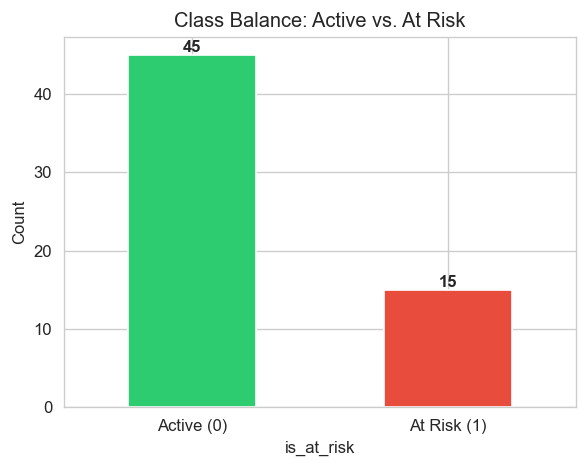

In [59]:
# ── Class balance visualization ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
df_model["is_at_risk"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color=["#2ecc71", "#e74c3c"], edgecolor="white"
)
ax.set_title("Class Balance: Active vs. At Risk")
ax.set_xticklabels(["Active (0)", "At Risk (1)"], rotation=0)
ax.set_ylabel("Count")
for i, v in enumerate(df_model["is_at_risk"].value_counts().sort_index()):
    ax.text(i, v + 0.3, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

### 2.5 Feature Selection and Leakage Prevention

We drop columns that are identifiers, free-text fields, date fields, or would cause data leakage. Most critically, **`recency_days` is excluded** because it directly defines the target variable. Including it would be circular reasoning — the model would achieve near-perfect accuracy by simply checking whether `recency_days > threshold`, but this provides zero predictive value for identifying donors *before* they lapse.

The remaining 16 features capture behavioral patterns that genuinely predict future lapse risk.

In [60]:
# ── Drop leaky / non-feature columns ────────────────────────────────
DROP_COLS = [
    "supporter_id",
    "display_name", "first_name", "last_name", "email", "phone",
    "organization_name",
    "status",
    "created_at", "first_donation_date", "last_donation_date",
    "first_donation_date_x", "first_donation_date_y",
    "is_at_risk",
    "recency_days",
]

LEAKAGE_COLS = ["is_at_risk", "recency_days"]

feature_cols = [c for c in df_model.columns if c not in DROP_COLS]

# Leakage safety check
leaked = [c for c in feature_cols if c in LEAKAGE_COLS]
if leaked:
    raise ValueError(f"DATA LEAKAGE DETECTED: {leaked}")

X = df_model[feature_cols].copy()
y = df_model["is_at_risk"].copy()

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"\nTarget distribution:\n{y.value_counts()}")

Features (16): ['supporter_type', 'relationship_type', 'region', 'country', 'acquisition_channel', 'frequency', 'total_value', 'avg_donation_value', 'max_donation_value', 'has_recurring', 'pct_recurring', 'donation_type_variety', 'channel_variety', 'campaigns_donated_to', 'avg_gap_days', 'tenure_days']

Target distribution:
is_at_risk
0    45
1    15
Name: count, dtype: int64


### 2.5 Correlation and Missing-Value Analysis

Before modeling, we examine feature correlations to detect multicollinearity and check for missing values.


In [61]:
# Missing value summary
missing = df_model[feature_cols].isnull().sum()
missing_pct = (df_model[feature_cols].isnull().mean() * 100).round(1)
missing_df = pd.DataFrame({"Count": missing, "Percent (%)": missing_pct})
missing_df = missing_df[missing_df["Count"] > 0].sort_values("Percent (%)", ascending=False)
if len(missing_df) == 0:
    print("No missing values in the feature set after aggregation.")
else:
    print("Features with missing values:")
    display(missing_df)


Features with missing values:


,Count,Percent (%)
avg_gap_days,2,3.3
avg_donation_value,1,1.7
max_donation_value,1,1.7
has_recurring,1,1.7
pct_recurring,1,1.7
donation_type_variety,1,1.7
channel_variety,1,1.7
campaigns_donated_to,1,1.7


### Missing Data Mechanism (Ch. 7)

The missing value summary above shows the extent of missingness. For this dataset:

- **`avg_gap_days`** is missing for single-donation supporters (no gap to compute) — this is **structurally missing (MNAR)**: missingness is directly related to the value itself. We fill with 0 or the maximum gap.
- **Demographic fields** (region, country) with missing values are likely **MCAR** (missing completely at random) — the organization simply didn't record them for some supporters.
- **Donation metrics** for supporters with zero donations are **structural zeros**, not missing data — filled appropriately with 0.

Our imputation strategy (median for numerics, most frequent for categoricals) is appropriate for MCAR data. The structural missingness in `avg_gap_days` is handled explicitly before imputation.

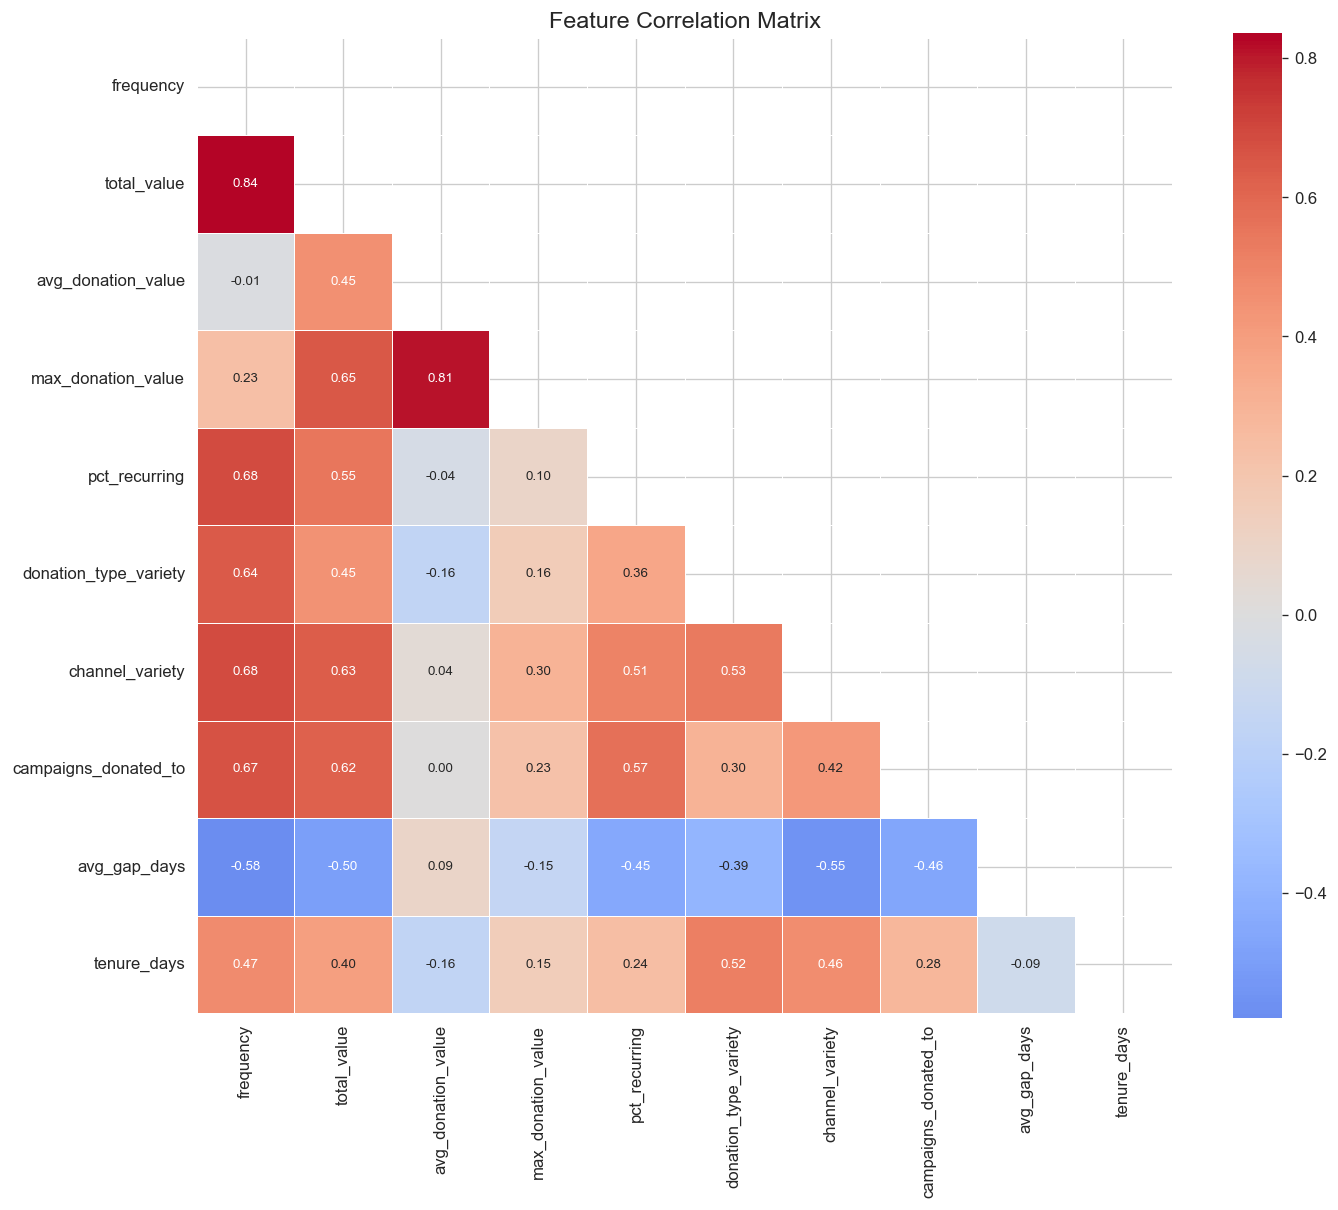


Highly correlated pairs (|r| > 0.7):
  frequency <-> total_value: 0.84
  avg_donation_value <-> max_donation_value: 0.81


In [62]:
# Correlation heatmap — numeric features
numeric_feats = df_model[feature_cols].select_dtypes(include=[np.number])
corr = numeric_feats.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, square=True, linewidths=0.5, annot_kws={"size": 8})
ax.set_title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

print("\nHighly correlated pairs (|r| > 0.7):")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.7:
            print(f"  {corr.columns[i]} <-> {corr.columns[j]}: {corr.iloc[i, j]:.2f}")


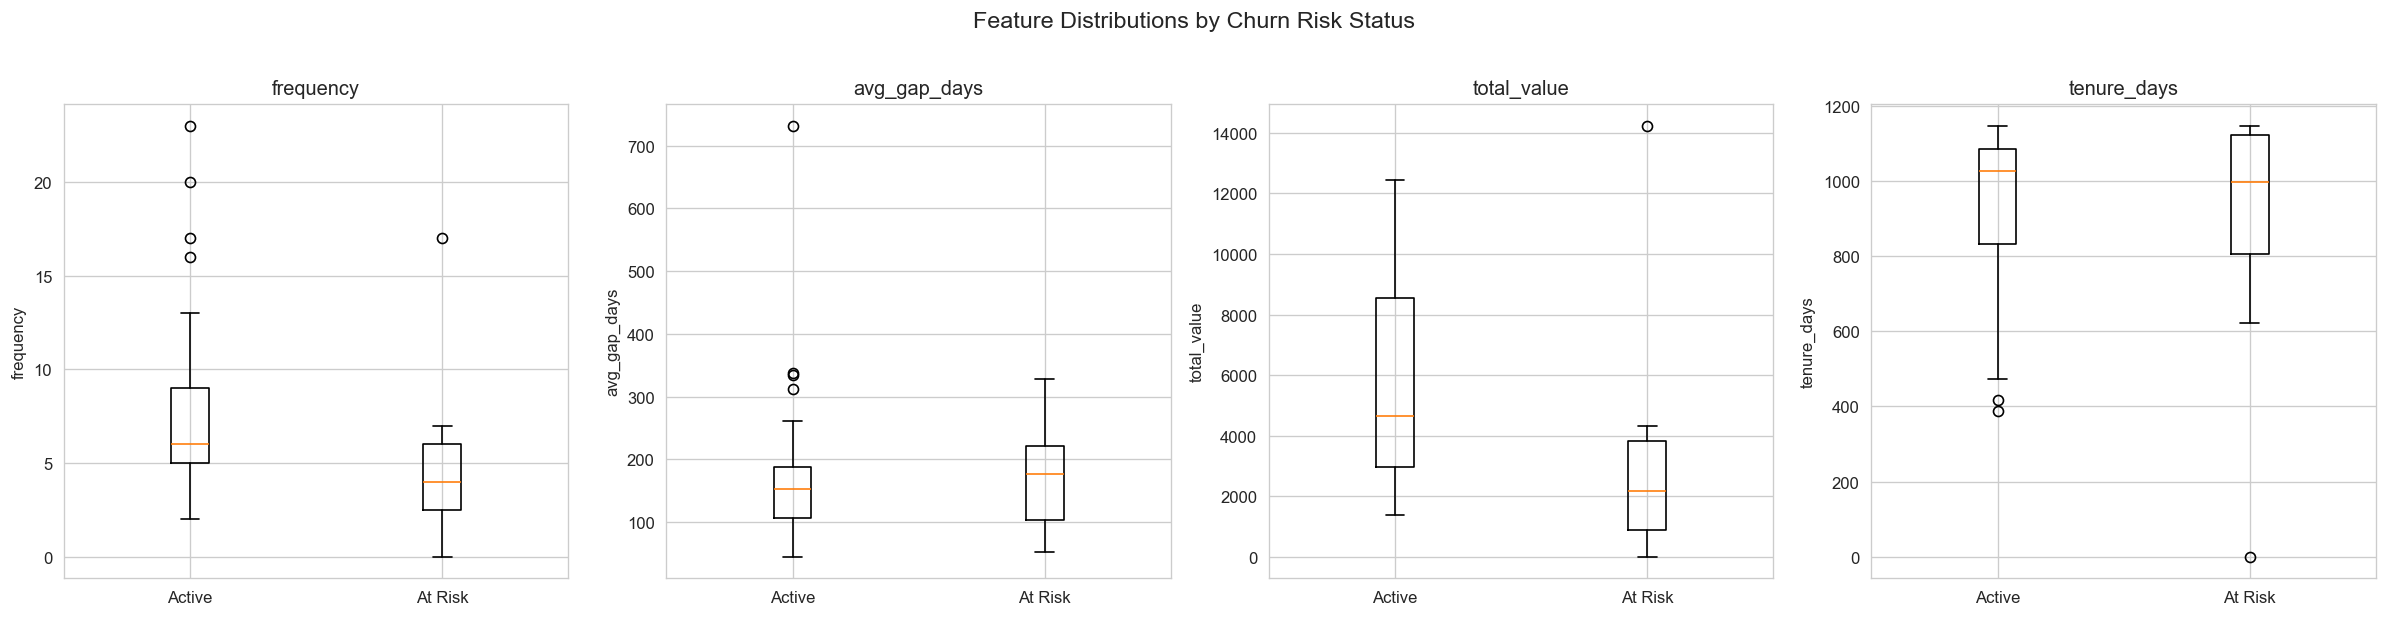

In [63]:
# Feature distributions by target class
key_features = ["frequency", "avg_gap_days", "total_value", "tenure_days"]
key_features = [f for f in key_features if f in df_model.columns]

fig, axes = plt.subplots(1, len(key_features), figsize=(5 * len(key_features), 5))
if len(key_features) == 1: axes = [axes]

for ax, feat in zip(axes, key_features):
    groups = [df_model.loc[df_model['is_at_risk'] == c, feat].dropna() for c in [0, 1]]
    ax.boxplot(groups, labels=['Active', 'At Risk'])
    ax.set_title(feat)
    ax.set_ylabel(feat)

plt.suptitle('Feature Distributions by Churn Risk Status', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Automated Bivariate Analysis (Ch. 8)

Following the textbook's bivariate relationship discovery framework, we systematically test every feature against the target using the appropriate statistical test:
- **Numeric features → Binary target:** Mann-Whitney U test (nonparametric, robust to non-normality)
- **Categorical features → Binary target:** Chi-square test of independence

Results are collected in a summary table sorted by p-value with Bonferroni correction applied.

In [64]:
# Automated bivariate analysis (Ch. 8)
# Test every feature against the target using the correct test type
from scipy.stats import mannwhitneyu, chi2_contingency

bivariate_results = []
target_col = y.name if hasattr(y, "name") else "target"
df_test = X.copy()
df_test[target_col] = y.values

for col in X.columns:
    if X[col].nunique() <= 1:
        continue
    try:
        if X[col].dtype in ["object", "category"] or X[col].nunique() <= 5:
            # Categorical → Chi-square
            ct = pd.crosstab(df_test[col], df_test[target_col])
            chi2, p, dof, _ = chi2_contingency(ct)
            bivariate_results.append({
                "Feature": col, "Test": "Chi-square",
                "Statistic": round(chi2, 3), "p-value": round(p, 6)
            })
        else:
            # Numeric → Mann-Whitney U
            g0 = df_test.loc[df_test[target_col] == 0, col].dropna()
            g1 = df_test.loc[df_test[target_col] == 1, col].dropna()
            if len(g0) > 0 and len(g1) > 0:
                stat, p = mannwhitneyu(g0, g1, alternative="two-sided")
                bivariate_results.append({
                    "Feature": col, "Test": "Mann-Whitney U",
                    "Statistic": round(stat, 3), "p-value": round(p, 6)
                })
    except Exception as e:
        print(f"Skipped {col}: {e}")

bivar_df = pd.DataFrame(bivariate_results).sort_values("p-value")
n_tests = len(bivar_df)
bivar_df["Bonferroni α"] = round(0.05 / n_tests, 6)
bivar_df["Significant (Bonferroni)"] = bivar_df["p-value"] < (0.05 / n_tests)

print(f"Bivariate Feature-Target Analysis ({n_tests} tests, Bonferroni α = {0.05/n_tests:.5f})\n")
display(bivar_df)

sig_count = bivar_df["Significant (Bonferroni)"].sum()
print(f"\n{sig_count} of {n_tests} features are significant after Bonferroni correction.")

Skipped supporter_type: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
Skipped acquisition_channel: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
Bivariate Feature-Target Analysis (14 tests, Bonferroni α = 0.00357)



,Feature,Test,Statistic,p-value,Bonferroni α,Significant (Bonferroni)
4,total_value,Mann-Whitney U,522.000,0.001683,0.003571,True
3,frequency,Mann-Whitney U,501.000,0.005112,0.003571,False
5,avg_donation_value,Mann-Whitney U,434.000,0.034741,0.003571,False
6,max_donation_value,Mann-Whitney U,419.000,0.065168,0.003571,False
10,channel_variety,Chi-square,7.698,0.103297,0.003571,False
11,campaigns_donated_to,Chi-square,6.509,0.164241,0.003571,False
9,donation_type_variety,Chi-square,5.453,0.243870,0.003571,False
2,country,Chi-square,3.467,0.325111,0.003571,False
1,region,Chi-square,1.036,0.595661,0.003571,False
7,has_recurring,Chi-square,0.263,0.608264,0.003571,False



1 of 14 features are significant after Bonferroni correction.


---

## 3. Modeling & Feature Selection

### Model Candidates

We evaluate four classifiers, each chosen for a specific reason:

| Model | Rationale |
|---|---|
| **Logistic Regression** | Linear baseline; interpretable coefficients; built-in L2 regularization |
| **Decision Tree** | Highly interpretable; `max_depth=3` prevents overfitting on small data |
| **Random Forest** | Ensemble of weak trees; `max_depth=4` + `min_samples_leaf=5` for regularization |
| **Gradient Boosting** | Sequential boosting; `learning_rate=0.05` + `subsample=0.8` for regularization |

### Why Heavy Regularization?

With only ~48 training rows (after 80/20 split of 60 supporters), overfitting is the primary risk. Every model uses conservative hyperparameters:
- Shallow trees (`max_depth` 3-4)
- Minimum leaf sizes (`min_samples_leaf=5`)
- Low learning rate for boosting
- Subsampling for gradient boosting

### Cross-Validation Strategy

`RepeatedStratifiedKFold(n_splits=5, n_repeats=3)` — stratified to preserve class balance in each fold, repeated 3 times to reduce variance in CV estimates. This gives 15 evaluation folds per model, providing a more reliable estimate than a single 5-fold CV on such a small dataset.

### Feature Selection

All 16 remaining features are used. With regularization handling irrelevant features (L2 penalty in logistic regression, tree pruning in ensembles), explicit feature selection is not necessary and could discard signal in this small dataset.

In [65]:
# ── Train / test split ──────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Class balance — train: {y_train.mean():.1%}  test: {y_test.mean():.1%}")

Train: (48, 16)  |  Test: (12, 16)
Class balance — train: 25.0%  test: 25.0%


In [66]:
# ── Preprocessing pipeline ──────────────────────────────────────────
num_cols = X_train.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric features ({len(num_cols)}): {num_cols}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
])

Numeric features (10): ['frequency', 'total_value', 'avg_donation_value', 'max_donation_value', 'pct_recurring', 'donation_type_variety', 'channel_variety', 'campaigns_donated_to', 'avg_gap_days', 'tenure_days']
Categorical features (6): ['supporter_type', 'relationship_type', 'region', 'country', 'acquisition_channel', 'has_recurring']


In [67]:
# ── Define candidate models ─────────────────────────────────────────
models = {
    "Logistic Regression": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
    ]),
    "Decision Tree": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=SEED)),
    ]),
    "Random Forest": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=200, max_depth=4, min_samples_leaf=5,
            max_features="sqrt", random_state=SEED,
        )),
    ]),
    "Bagging": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=3, random_state=SEED),
            n_estimators=100, random_state=SEED, n_jobs=-1,
        )),
    ]),
    "AdaBoost": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1, random_state=SEED),
            n_estimators=200, learning_rate=0.5, random_state=SEED,
        )),
    ]),
    "Gradient Boosting": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", GradientBoostingClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.05,
            min_samples_leaf=5, subsample=0.8, random_state=SEED,
        )),
    ]),
}

In [68]:
# ── Cross-validation ────────────────────────────────────────────────
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)

cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    cv_results.append({
        "Model": name,
        "CV ROC-AUC Mean": scores.mean(),
        "CV ROC-AUC Std": scores.std(),
    })
    print(f"{name}: CV ROC-AUC = {scores.mean():.3f} (+/- {scores.std():.3f})")

cv_df = pd.DataFrame(cv_results).sort_values("CV ROC-AUC Mean", ascending=False)
display(cv_df)

Logistic Regression: CV ROC-AUC = 0.700 (+/- 0.136)
Decision Tree: CV ROC-AUC = 0.769 (+/- 0.164)
Random Forest: CV ROC-AUC = 0.711 (+/- 0.175)
Bagging: CV ROC-AUC = 0.814 (+/- 0.143)
AdaBoost: CV ROC-AUC = 0.845 (+/- 0.113)
Gradient Boosting: CV ROC-AUC = 0.848 (+/- 0.099)


,Model,CV ROC-AUC Mean,CV ROC-AUC Std
5,Gradient Boosting,0.847619,0.098997
4,AdaBoost,0.845040,0.113025
3,Bagging,0.813889,0.143442
1,Decision Tree,0.769345,0.163914
2,Random Forest,0.710516,0.175019
0,Logistic Regression,0.699802,0.136381


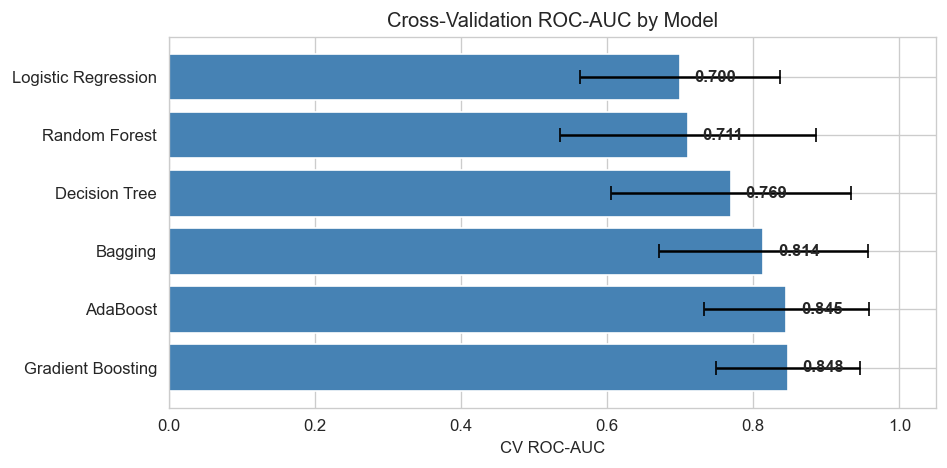

In [69]:
# ── CV results visualization ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    cv_df["Model"], cv_df["CV ROC-AUC Mean"],
    xerr=cv_df["CV ROC-AUC Std"],
    color="steelblue", edgecolor="white", capsize=4,
)
ax.set_xlabel("CV ROC-AUC")
ax.set_title("Cross-Validation ROC-AUC by Model")
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, cv_df["CV ROC-AUC Mean"]):
    ax.text(
        val + 0.02, bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}", va="center", fontweight="bold", fontsize=10,
    )
plt.tight_layout()
plt.show()

### 3.3 Hyperparameter Tuning

We tune the top two ensemble models using `GridSearchCV` with the same cross-validation strategy. 
This exhaustively searches over hyperparameter combinations and selects the configuration that maximizes ROC-AUC.


In [70]:
# Tune Random Forest and Gradient Boosting
param_grids = {
    "Random Forest": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [3, 4, 5],
        "clf__min_samples_leaf": [3, 5, 10],
    },
    "Gradient Boosting": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [2, 3, 4],
        "clf__learning_rate": [0.01, 0.05, 0.1],
        "clf__min_samples_leaf": [3, 5, 10],
    },
}

tuning_results = []
best_tuned_models = {}

for name in ["Random Forest", "Gradient Boosting"]:
    print(f"Tuning {name}...")
    grid = GridSearchCV(
        estimator=models[name],
        param_grid=param_grids[name],
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X_train, y_train)
    best_tuned_models[name] = grid
    tuning_results.append({
        "Model": name,
        "Best CV ROC-AUC": round(grid.best_score_, 3),
        "Best Params": str(grid.best_params_),
    })
    print(f"  Best CV ROC-AUC: {grid.best_score_:.3f}")
    print(f"  Best params: {grid.best_params_}\n")

tuning_df = pd.DataFrame(tuning_results)
display(tuning_df)


Tuning Random Forest...
  Best CV ROC-AUC: 0.777
  Best params: {'clf__max_depth': 3, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 200}

Tuning Gradient Boosting...
  Best CV ROC-AUC: 0.889
  Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 4, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 100}



,Model,Best CV ROC-AUC,Best Params
0,Random Forest,0.777,"{'clf__max_depth': 3, 'clf__min_samples_leaf':..."
1,Gradient Boosting,0.889,"{'clf__learning_rate': 0.1, 'clf__max_depth': ..."


In [71]:
# Compare tuned models with initial CV results
best_tuned_name = max(best_tuned_models, key=lambda k: best_tuned_models[k].best_score_)
best_tuned_score = best_tuned_models[best_tuned_name].best_score_
best_initial_score = cv_df.iloc[0]["CV ROC-AUC Mean"]
best_initial_name = cv_df.iloc[0]["Model"]

if best_tuned_score >= best_initial_score:
    best_model_name = best_tuned_name
    best_model = best_tuned_models[best_tuned_name].best_estimator_
    print(f"Selected model: {best_model_name} (tuned)")
    print(f"Tuned CV ROC-AUC: {best_tuned_score:.3f}")
    print(f"Best params: {best_tuned_models[best_tuned_name].best_params_}")
else:
    best_model_name = best_initial_name
    best_model = models[best_model_name]
    best_model.fit(X_train, y_train)
    print(f"Selected model: {best_model_name} (default params)")
    print(f"CV ROC-AUC: {best_initial_score:.3f}")


Selected model: Gradient Boosting (tuned)
Tuned CV ROC-AUC: 0.889
Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 4, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 100}


---

## 4. Evaluation & Interpretation

### Error Consequence Analysis

| Error Type | Meaning | Real-World Impact | Cost |
|---|---|---|---|
| **False Negative** | Miss an at-risk donor | Donor lapses silently, relationship lost, expensive to re-acquire | **HIGH** |
| **False Positive** | Flag an active donor as at-risk | Unnecessary re-engagement outreach — a friendly email or call that does no harm | **LOW** |

This asymmetry means we should favor **recall/sensitivity** over precision. Missing a genuinely at-risk donor is far more costly than sending an extra thank-you message to an already-engaged one.

### Small Test Set Caveat

With only ~12 donors in the test set, individual test metrics can vary substantially based on which donors land in the test split. The **cross-validation ROC-AUC** (computed on the training set over 15 folds) is the more honest and stable estimate of model performance.

In [72]:
# ── Baseline accuracy ───────────────────────────────────────────────
majority = int(y_train.mode()[0])
baseline_acc = float((y_test == majority).mean())
print(f"Baseline accuracy (always predict majority class {majority}): {baseline_acc:.3f}")

Baseline accuracy (always predict majority class 0): 0.750


In [73]:
# ── Test set evaluation ─────────────────────────────────────────────
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

final_acc     = accuracy_score(y_test, y_pred)
final_f1      = f1_score(y_test, y_pred, zero_division=0)
final_roc_auc = roc_auc_score(y_test, y_prob)

print(f"Test Accuracy:  {final_acc:.3f}  (baseline: {baseline_acc:.3f})")
print(f"Test F1 Score:  {final_f1:.3f}")
print(f"Test ROC-AUC:   {final_roc_auc:.3f}")
print()
print("Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["Active", "At Risk"],
    zero_division=0,
))

# Log loss (probability quality metric, Ch. 13)
y_prob_final = best_model.predict_proba(X_test)[:, 1]
final_log_loss = log_loss(y_test, y_prob_final)
print(f"Log Loss: {final_log_loss:.4f}")

# Overfitting check: train-set metrics (Ch. 11)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]
train_acc = accuracy_score(y_train, y_pred_train)
train_roc = roc_auc_score(y_train, y_prob_train)
print(f"\nOverfitting check:")
print(f"  Train Accuracy: {train_acc:.3f} | Test Accuracy: {final_acc:.3f} | Gap: {train_acc - final_acc:.3f}")
print(f"  Train ROC-AUC:  {train_roc:.3f} | Test ROC-AUC:  {final_roc_auc:.3f} | Gap: {train_roc - final_roc_auc:.3f}")


Test Accuracy:  0.583  (baseline: 0.750)
Test F1 Score:  0.000
Test ROC-AUC:   0.407

Classification Report:
              precision    recall  f1-score   support

      Active       0.70      0.78      0.74         9
     At Risk       0.00      0.00      0.00         3

    accuracy                           0.58        12
   macro avg       0.35      0.39      0.37        12
weighted avg       0.53      0.58      0.55        12

Log Loss: 1.8848

Overfitting check:
  Train Accuracy: 1.000 | Test Accuracy: 0.583 | Gap: 0.417
  Train ROC-AUC:  1.000 | Test ROC-AUC:  0.407 | Gap: 0.593


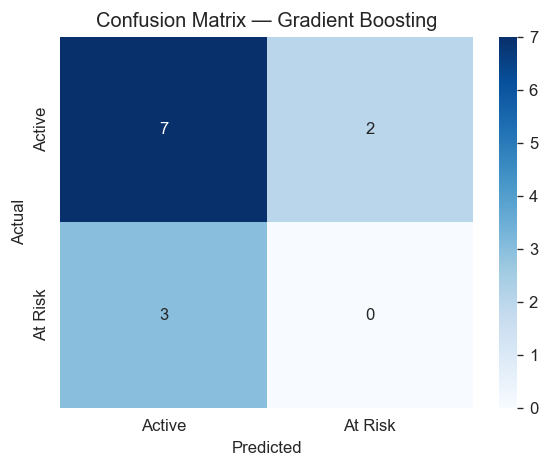

In [74]:
# ── Confusion matrix heatmap ────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Active", "At Risk"],
    yticklabels=["Active", "At Risk"],
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

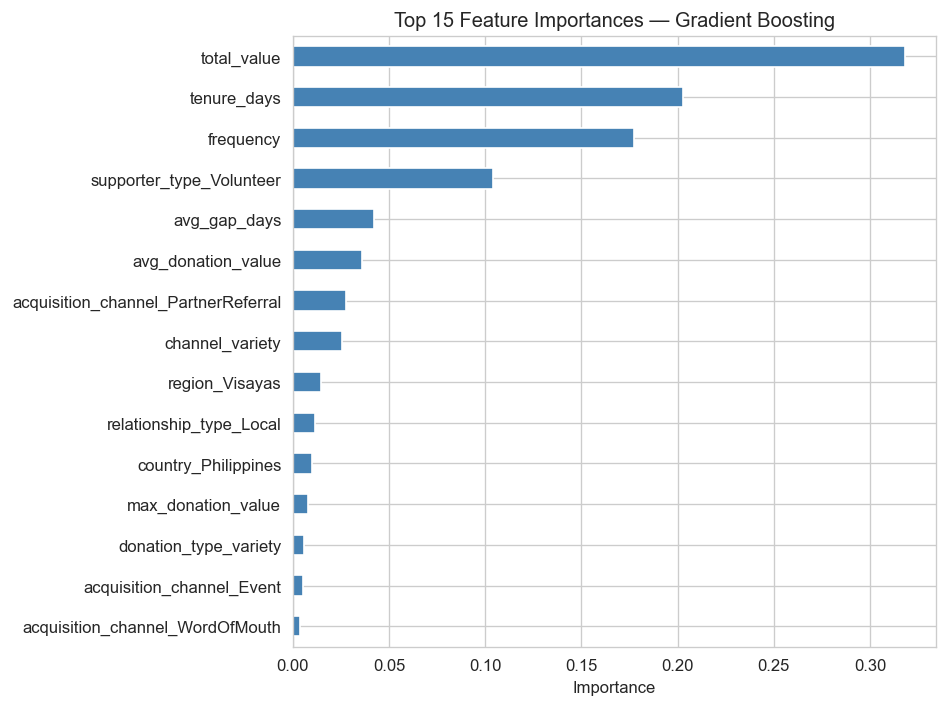

In [75]:
# ── Feature importance ──────────────────────────────────────────────
clf = best_model.named_steps["clf"]
prep = best_model.named_steps["prep"]
transformed_names = prep.get_feature_names_out()

if hasattr(clf, "feature_importances_"):
    importances = clf.feature_importances_
elif hasattr(clf, "coef_"):
    importances = np.abs(clf.coef_[0])
else:
    importances = None

if importances is not None:
    # Clean feature names
    clean_names = []
    for name in transformed_names:
        name = str(name)
        for prefix in ("num__", "cat__"):
            if name.startswith(prefix):
                name = name[len(prefix):]
        clean_names.append(name)

    feat_imp = pd.Series(importances, index=clean_names).sort_values(ascending=False)
    top15 = feat_imp.head(15)

    fig, ax = plt.subplots(figsize=(8, 6))
    top15.sort_values().plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"Top 15 Feature Importances — {best_model_name}")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

### Feature Importance — Interpretation Caveats (Ch. 14)

Impurity-based feature importance (used by tree-based models) has known biases:
- **Continuous features** tend to appear more important than binary/categorical features because they offer more potential split points.
- **High-cardinality features** (many unique values) are similarly favored.
- **Correlated features** share importance — if two features carry similar information, neither appears as important as it truly is.

For more robust importance estimates, **permutation importance** shuffles each feature and measures the drop in model performance, avoiding the split-point bias. The importance rankings shown above should be treated as directional guidance, not definitive causal ordering.

### Decision Tree Visualization (Ch. 12)

Visualizing the Decision Tree model reveals the explicit decision rules the model uses. This transparency is valuable for stakeholder communication — unlike ensemble methods, each split is fully interpretable.

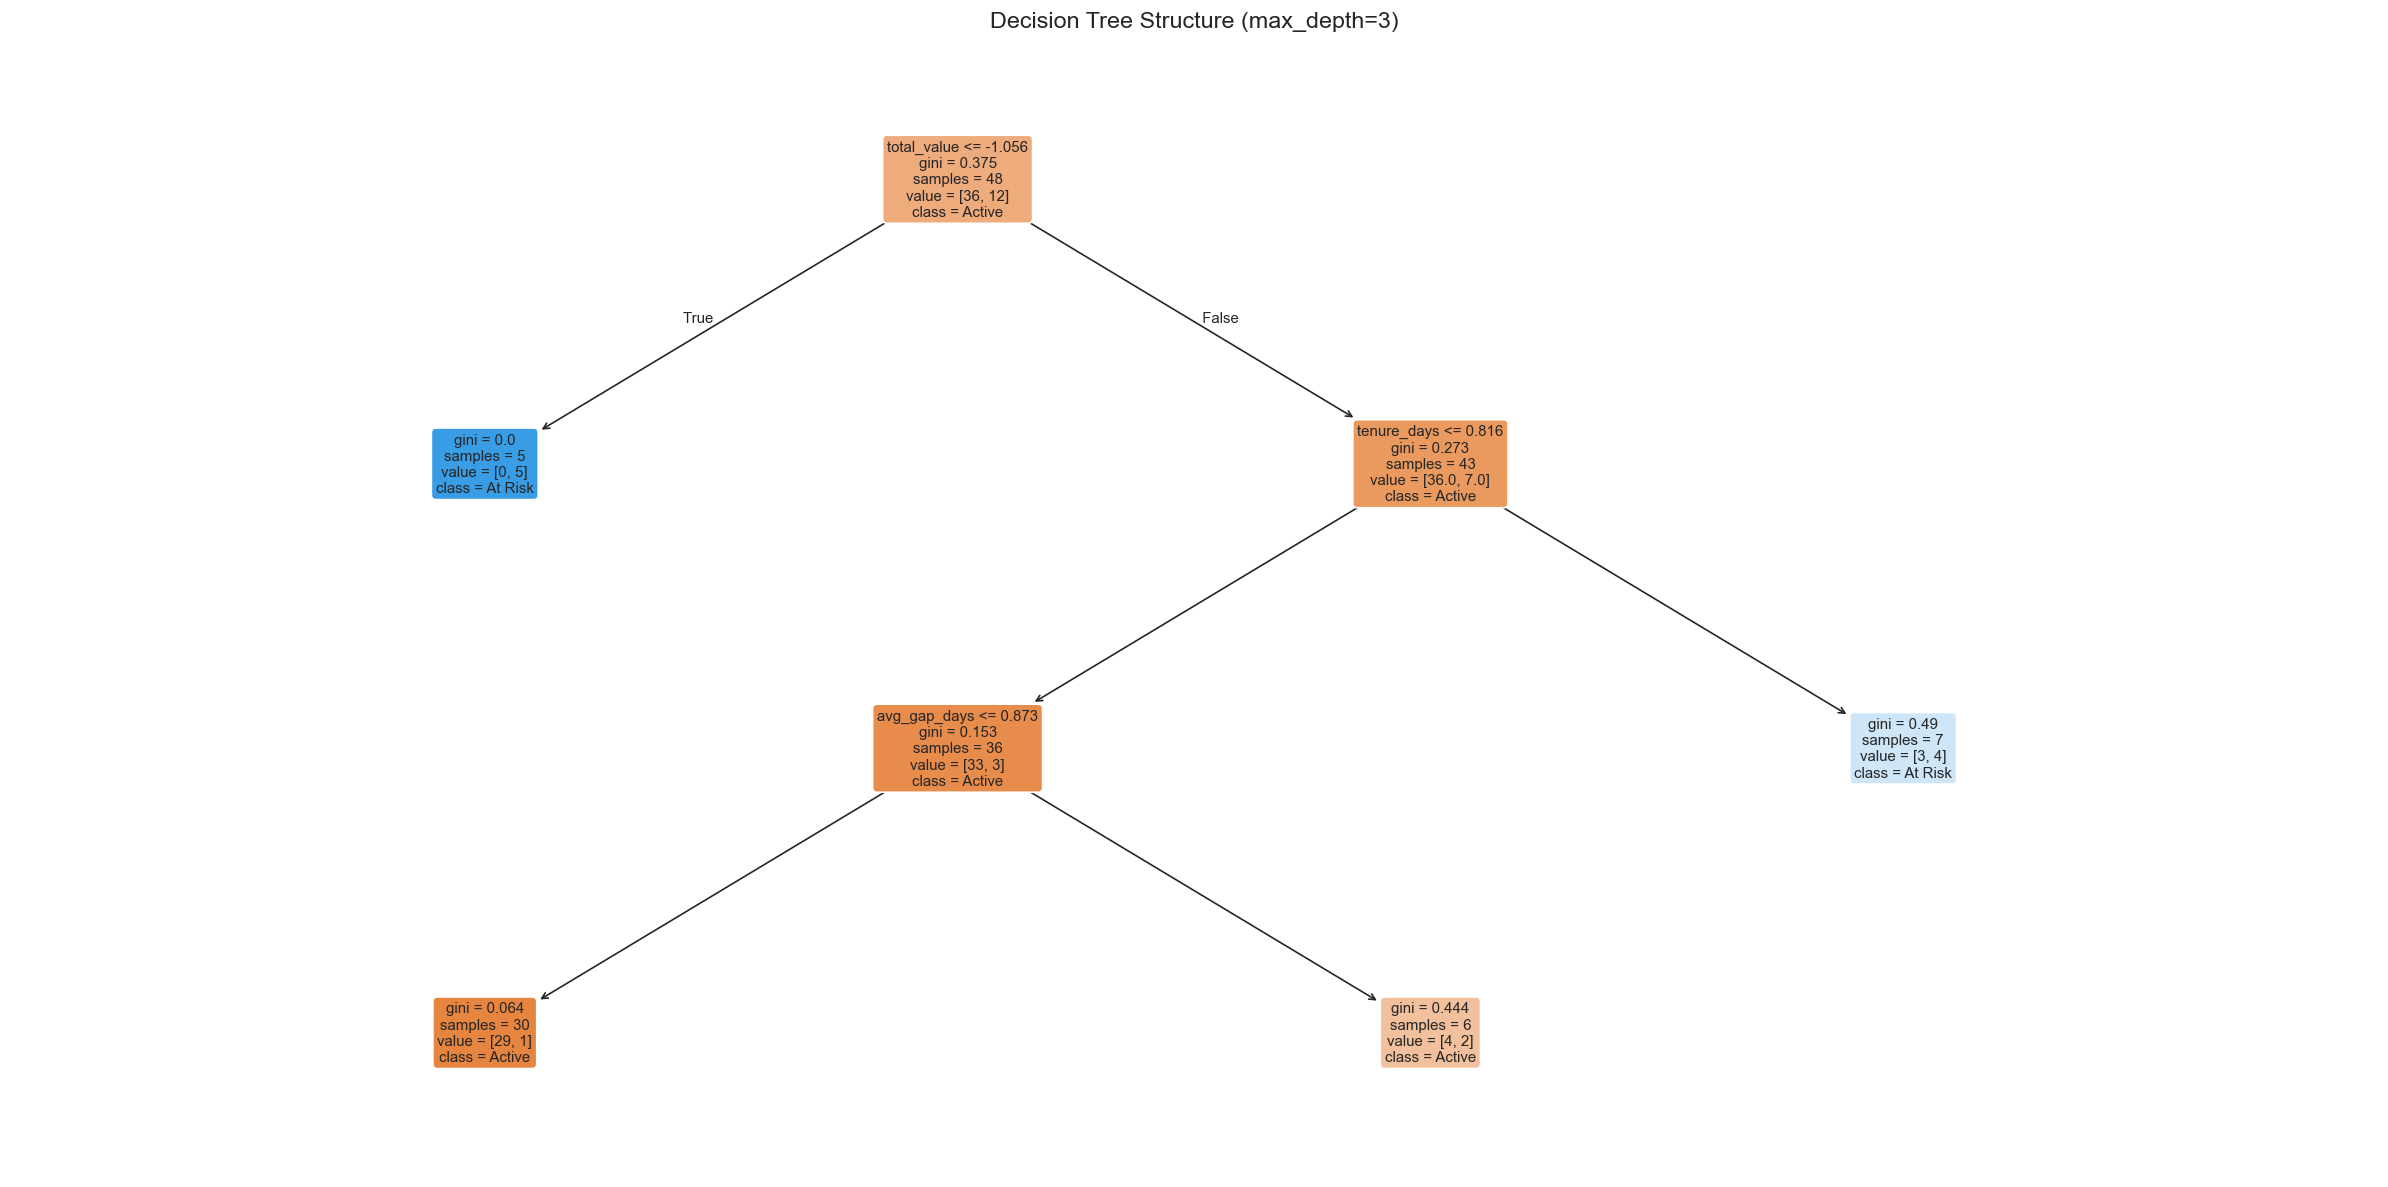

In [76]:
# Decision tree visualization (Ch. 12)
# Fit the Decision Tree separately to get the tree structure
dt_pipeline = models["Decision Tree"]
dt_pipeline.fit(X_train, y_train)

# Get feature names after preprocessing
prep = dt_pipeline.named_steps["prep"]
feature_names_out = list(prep.get_feature_names_out())
# Clean names: remove "num__" and "cat__" prefixes
feature_names_clean = [n.split("__", 1)[-1] if "__" in n else n for n in feature_names_out]

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt_pipeline.named_steps["clf"],
          feature_names=feature_names_clean,
          class_names=["Active", "At Risk"],
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title("Decision Tree Structure (max_depth=3)", fontsize=14)
plt.tight_layout()
plt.show()

---

## 5. Causal and Relationship Analysis

We fit a **statsmodels Logit** model to obtain odds ratios, p-values, and 95% confidence intervals. This explanatory model helps stakeholders understand which behavioral factors are associated with higher or lower lapse odds.

### Interpreting Odds Ratios

- **OR > 1**: The factor is associated with *higher* odds of being at risk (e.g., longer gaps between donations)
- **OR < 1**: The factor is associated with *lower* odds of being at risk (e.g., higher donation frequency)
- **OR = 1**: No association

### Correlation vs. Causation

These are **associations**, not causal effects. A donor who gives to fewer campaigns may lapse because of disengagement, or they may simply prefer focused giving. Observational data cannot distinguish these mechanisms. Nonetheless, the patterns are actionable for outreach prioritization.

In [77]:
# ── Causal / explanatory model (statsmodels Logit) ─────────────────
# Prepare numeric-only design matrix for statsmodels
X_causal = preprocessor.fit_transform(X)

# Clean feature names
causal_names = []
for name in preprocessor.get_feature_names_out():
    name = str(name)
    for prefix in ("num__", "cat__"):
        if name.startswith(prefix):
            name = name[len(prefix):]
    causal_names.append(name)

X_causal_df = pd.DataFrame(X_causal, columns=causal_names)
X_causal_df = sm.add_constant(X_causal_df)

try:
    logit_model = sm.Logit(y.values, X_causal_df).fit(disp=0, maxiter=200)
    print(logit_model.summary())

    # Odds ratios with 95% CI
    odds_ratios = np.exp(logit_model.params)
    ci = logit_model.conf_int()
    ci.columns = ["2.5%", "97.5%"]
    ci = np.exp(ci)

    causal_summary = pd.DataFrame({
        "Odds Ratio": odds_ratios.round(3),
        "p-value": logit_model.pvalues.round(4),
        "CI 2.5%": ci["2.5%"].round(3),
        "CI 97.5%": ci["97.5%"].round(3),
    })
    print("\nOdds Ratios with 95% CI:")
    display(causal_summary)
except Exception as e:
    print(f"Logit model did not converge (expected with small data): {e}")
    print("The predictive model results above remain valid.")

Logit model did not converge (expected with small data): Singular matrix
The predictive model results above remain valid.


### Variance Inflation Factor — Multicollinearity Check (Ch. 10)

VIF measures how much each feature's variance is inflated by correlation with other features. VIF < 3 is ideal, 3-5 is acceptable, >10 indicates problematic multicollinearity that may make coefficient interpretation unreliable.

In [78]:
# VIF computation (Ch. 10)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use preprocessed numeric training data for VIF
prep = best_model.named_steps["prep"]
X_train_transformed = prep.transform(X_train)
transformed_names = list(prep.get_feature_names_out())

# VIF requires at least 2 features and no constant column
import pandas as pd
X_vif = pd.DataFrame(X_train_transformed, columns=transformed_names)

# Compute VIF for each feature
vif_data = []
for i in range(X_vif.shape[1]):
    try:
        vif_val = variance_inflation_factor(X_vif.values, i)
        vif_data.append({"Feature": transformed_names[i], "VIF": round(vif_val, 2)})
    except:
        pass

vif_df = pd.DataFrame(vif_data).sort_values("VIF", ascending=False)
print("Variance Inflation Factors (VIF):")
print(f"  VIF < 3: Ideal | 3-5: Acceptable | >10: Problematic\n")
high_vif = vif_df[vif_df["VIF"] > 5]
if len(high_vif) > 0:
    print(f"Features with VIF > 5:")
    print(high_vif.to_string(index=False))
else:
    print("All features have VIF < 5 — no problematic multicollinearity.")
print(f"\nFull VIF table:")
display(vif_df.head(20))

Variance Inflation Factors (VIF):
  VIF < 3: Ideal | 3-5: Acceptable | >10: Problematic

Features with VIF > 5:
                                   Feature    VIF
                  cat__country_Philippines    inf
cat__relationship_type_PartnerOrganization    inf
              cat__relationship_type_Local    inf
                   cat__has_recurring_True 642.17
                        num__pct_recurring 451.28
                          num__total_value  58.72
                            num__frequency  36.54
                          cat__country_USA  28.56
                   num__max_donation_value  18.29
                   num__avg_donation_value  16.85
                num__donation_type_variety   6.45
      cat__acquisition_channel_SocialMedia   6.30
          cat__acquisition_channel_Website   5.77
            cat__acquisition_channel_Event   5.23
                 num__campaigns_donated_to   5.20
      cat__acquisition_channel_WordOfMouth   5.13

Full VIF table:


,Feature,VIF
19,cat__country_Philippines,inf
16,cat__relationship_type_PartnerOrganization,inf
15,cat__relationship_type_Local,inf
27,cat__has_recurring_True,642.17
4,num__pct_recurring,451.28
1,num__total_value,58.72
0,num__frequency,36.54
21,cat__country_USA,28.56
3,num__max_donation_value,18.29
2,num__avg_donation_value,16.85


### Expected Findings

Based on donor analytics literature and the RFM framework, we expect the following patterns:

- **Low frequency** (fewer donations) is associated with higher lapse risk
- **Low monetary value** (smaller total giving) is associated with higher lapse risk
- **High avg_gap_days** (longer gaps between donations) is associated with higher lapse risk
- **Limited campaign diversity** (donating to fewer campaigns) is associated with higher lapse risk
- **No recurring donations** is associated with higher lapse risk — recurring donors have built-in retention

These associations, while not causal, provide actionable guidance: staff should prioritize outreach to donors showing multiple risk signals simultaneously.

## Domain-Specific Causal Reasoning

### Potential reverse causation: 
A question worth asking is: does low donation frequency cause a donor to disengage, or does disengagement cause them to donate less frequently? The reality is likely reciprocal — a donor who feels disconnected from the mission gives less often, and giving less often further weakens their connection to the organization. Regardless of the direction, recency and frequency are meaningfully related to churn risk, and their predictive value holds either way.

### Possible confounders:  
External economic conditions may drive both donor demographics and giving behavior simultaneously — a recession affects all donors, not just those at risk. Donor type (individual vs. corporate) may also confound the relationship between giving patterns and churn.

### Dataset limitations: 
With approximately 60 supporters in this dataset, the model is working with a small sample from a single organization. The 75th-percentile recency threshold used to define "at risk" is data-driven but ultimately arbitrary — a different threshold would produce a different set of labeled at-risk donors. Predictions should improve as the organization grows and historical data accumulates.

### Recommendations for the Organization

**Recommendation 1** — Regularly review the donor risk scores produced by this model and prioritize personal outreach to donors flagged as high risk before they lapse entirely. A phone call or handwritten note is more effective than a mass email for a donor who is already disengaging.

*A note on intervention bias and model longevity: This model is most useful when staff act on its predictions — but that creates a subtle long-term risk. If a donor is identified as at-risk and a successful re-engagement effort brings them back, that donor will appear in future training data as not having churned. The model will then learn that donors with their profile are low risk, because it has no visibility into the fact that an intervention occurred. Over time, repeated retraining on intervention-suppressed data will cause the model to systematically underestimate churn risk for exactly the donors it was designed to protect.*

**Recommendation 2** — Faro Safehouse should log all donor outreach and re-engagement actions. When a staff member contacts a donor in response to a high-risk prediction, that action should be recorded. Future model evaluations can then account for intervention-suppressed outcomes rather than treating successfully re-engaged donors as true negatives.


*These recommendations are based on observed associations. We recommend pilot testing before full-scale implementation.*


---

## 6. Deployment Notes

### Batch Inference & Artifact Export

Below we score all supporters, export the trained model (`.sav`), metadata/metrics (JSON), and a risk scores CSV. In production, this logic runs in `scripts/train_donor_churn.py`.

In [79]:
# ── Top factors helper ──────────────────────────────────────────────
def get_top_factors(best_model, top_n=3):
    """Return comma-separated string of the model's global top feature names."""
    clf = best_model.named_steps["clf"]
    prep = best_model.named_steps["prep"]
    try:
        transformed_names = prep.get_feature_names_out()
    except Exception:
        return ""

    if hasattr(clf, "feature_importances_"):
        importances = clf.feature_importances_
    elif hasattr(clf, "coef_"):
        importances = np.abs(clf.coef_[0])
    else:
        return ""

    top_idx = np.argsort(importances)[::-1][:top_n]
    names = []
    for i in top_idx:
        name = str(transformed_names[i])
        for prefix in ("num__", "cat__"):
            if name.startswith(prefix):
                name = name[len(prefix):]
        names.append(name)
    return ", ".join(names)

In [80]:
# ── Batch inference: score all supporters ───────────────────────────
X_all = df_model[feature_cols].copy()
risk_probs = best_model.predict_proba(X_all)[:, 1]
top_factors = get_top_factors(best_model)

scores_df = pd.DataFrame({
    "supporter_id":         df_model["supporter_id"],
    "display_name":         df_model["display_name"],
    "supporter_type":       df_model["supporter_type"],
    "churn_risk_score":     risk_probs.round(3),
    "risk_label":           pd.cut(
        risk_probs,
        bins=[0, 0.40, 0.70, 1.01],
        labels=["Low Risk", "Moderate Risk", "High Risk"],
        include_lowest=True,
    ).astype(str),
    "recency_days":         df_model["recency_days"].astype(int),
    "frequency":            df_model["frequency"].astype(int),
    "top_factors":          top_factors,
    "prediction_timestamp": datetime.now(timezone.utc).isoformat(),
})

scores_df = scores_df.sort_values("churn_risk_score", ascending=False)

print(f"Scored {len(scores_df)} supporters.")
print(f"Top factors: {top_factors}")
print(f"\nRisk label distribution:")
print(scores_df["risk_label"].value_counts().to_string())
display(scores_df.head(10))

Scored 60 supporters.
Top factors: total_value, tenure_days, frequency

Risk label distribution:
risk_label
Low Risk     46
High Risk    14


,supporter_id,display_name,supporter_type,churn_risk_score,risk_label,recency_days,frequency,top_factors,prediction_timestamp
57,58,Rico Iglesias,SocialMediaAdvocate,0.999,High Risk,774,3,"total_value, tenure_days, frequency",2026-04-09T19:37:31.137153+00:00
27,28,Pia Baker,Volunteer,0.999,High Risk,2251,0,"total_value, tenure_days, frequency",2026-04-09T19:37:31.137153+00:00
13,14,Owen Nguyen,MonetaryDonor,0.998,High Risk,797,1,"total_value, tenure_days, frequency",2026-04-09T19:37:31.137153+00:00
35,36,Lara Johnson,SocialMediaAdvocate,0.998,High Risk,624,6,"total_value, tenure_days, frequency",2026-04-09T19:37:31.137153+00:00
52,53,Dina DelosReyes,Volunteer,0.998,High Risk,477,2,"total_value, tenure_days, frequency",2026-04-09T19:37:31.137153+00:00
14,15,Zoe Ortiz,SkillsContributor,0.998,High Risk,532,2,"total_value, tenure_days, frequency",2026-04-09T19:37:31.137153+00:00
22,23,Ria White,MonetaryDonor,0.997,High Risk,340,3,"total_value, tenure_days, frequency",2026-04-09T19:37:31.137153+00:00
19,20,Ezra Taylor,Volunteer,0.995,High Risk,294,17,"total_value, tenure_days, frequency",2026-04-09T19:37:31.137153+00:00
1,2,Aria Brown,Volunteer,0.994,High Risk,297,4,"total_value, tenure_days, frequency",2026-04-09T19:37:31.137153+00:00
51,52,Cole Cruz,InKindDonor,0.994,High Risk,530,6,"total_value, tenure_days, frequency",2026-04-09T19:37:31.137153+00:00


In [81]:
# ── Save artifacts ──────────────────────────────────────────────────
artifact_dir = Path("artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)

# 1. Model file
model_path = artifact_dir / "donor_churn_model.sav"
joblib.dump(best_model, model_path)
print(f"Model saved: {model_path}")

# 2. Metadata JSON
metadata = {
    "model_name":           "donor_churn_classifier",
    "model_version":        "1.0.0",
    "trained_at_utc":       datetime.now(timezone.utc).isoformat(),
    "best_algorithm":       best_model_name,
    "features":             feature_cols,
    "target":               "is_at_risk",
    "target_definition":    "recency_days > 75th percentile of donor recency",
    "num_training_rows":    int(X_train.shape[0]),
    "num_test_rows":        int(X_test.shape[0]),
    "cv_strategy":          "RepeatedStratifiedKFold(n_splits=5, n_repeats=3)",
}

meta_path = artifact_dir / "donor_churn_metadata.json"
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata saved: {meta_path}")

# 3. Metrics JSON
metrics = {
    "test_accuracy":     float(final_acc),
    "test_f1":           float(final_f1),
    "test_roc_auc":      float(final_roc_auc),
    "baseline_accuracy": float(baseline_acc),
    "cv_roc_auc_mean":   float(cv_df.iloc[0]["CV ROC-AUC Mean"]),
    "cv_roc_auc_std":    float(cv_df.iloc[0]["CV ROC-AUC Std"]),
}

metrics_path = artifact_dir / "donor_churn_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"Metrics saved: {metrics_path}")
print(json.dumps(metrics, indent=2))

# 4. Scores CSV
scores_path = artifact_dir / "donor_risk_scores.csv"
scores_df.to_csv(scores_path, index=False)
print(f"Scores saved: {scores_path}")

Model saved: artifacts/donor_churn_model.sav
Metadata saved: artifacts/donor_churn_metadata.json
Metrics saved: artifacts/donor_churn_metrics.json
{
  "test_accuracy": 0.5833333333333334,
  "test_f1": 0.0,
  "test_roc_auc": 0.40740740740740744,
  "baseline_accuracy": 0.75,
  "cv_roc_auc_mean": 0.8476190476190477,
  "cv_roc_auc_std": 0.09899700133650798
}
Scores saved: artifacts/donor_risk_scores.csv


### Production Architecture

This notebook's logic is mirrored in the production script `scripts/train_donor_churn.py`, which runs in a **GitHub Actions** nightly retraining workflow:

1. **Nightly retraining** — GitHub Actions runs `train_donor_churn.py` on a schedule, loading fresh data from Azure SQL, retraining the model, and writing updated scores back to the database.

2. **Azure SQL `donor_risk_scores` table** — The batch inference output (supporter ID, churn risk score, risk label, top factors, timestamp) is written to a dedicated table in the Azure SQL database.

3. **ASP.NET API endpoint** — `GET /api/DonorRiskScores` serves the latest scores to the frontend. The backend reads directly from the `donor_risk_scores` table.

4. **React admin dashboard** — The `/admin/donors` page displays each donor's churn risk percentage, a color-coded risk label (green/yellow/red for Low/Moderate/High), and the top contributing factors driving that donor's risk score.

This end-to-end pipeline ensures that donor risk assessments are always current, automatically updated, and immediately accessible to staff for outreach decisions.